### **BBC NEWS CLASSIFICATION - FINE TUNING DISTILBERT**

### Importing Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import label_binarize
import torch
from transformers import (DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments,EarlyStoppingCallback)
from datasets import Dataset
import warnings
warnings.filterwarnings('ignore')

C:\Users\Siddhi\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


### Loading the dataset

In [5]:
print("\n" + "="*60)
print("LOADING DATASET")
print("="*60)

df = pd.read_csv('bbc_news.csv')
print(f"Data loaded: {len(df)} articles")
print(f"Categories: {df['label'].unique()}")
print(f"\nClass distribution:\n{df['label'].value_counts()}")


LOADING DATASET
Data loaded: 2225 articles
Categories: ['business' 'entertainment' 'politics' 'sport' 'tech']

Class distribution:
label
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


### Create label mappings

In [7]:
print("\n" + "="*60)
print("CREATING LABEL MAPPINGS")
print("="*60)

categories = sorted(df['label'].unique())
label2id = {label: i for i, label in enumerate(categories)}
id2label = {i: label for label, i in label2id.items()}

df['labels'] = df['label'].map(label2id)
print(f"Label mapping: {label2id}")


CREATING LABEL MAPPINGS
Label mapping: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


### Train-Validation-Test split

In [9]:
print("\n" + "="*60)
print("SPLITTING DATA")
print("="*60)

# 60% train, 20% validation, 20% test
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain distribution:\n{train_df['label'].value_counts()}")


SPLITTING DATA
Train: 1335 | Validation: 445 | Test: 445

Train distribution:
label
sport            311
business         297
politics         258
tech             237
entertainment    232
Name: count, dtype: int64


### Tokenization

In [11]:
print("\n" + "="*60)
print("TOKENIZING DATA")
print("="*60)

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize_text(examples):
    """Tokenize text with proper padding and truncation"""
    return tokenizer(
        examples['text'], 
        padding='max_length', 
        truncation=True, 
        max_length=128
    )

# Convert to HuggingFace dataset format
train_dataset = Dataset.from_pandas(train_df[['text', 'labels']])
val_dataset = Dataset.from_pandas(val_df[['text', 'labels']])
test_dataset = Dataset.from_pandas(test_df[['text', 'labels']])

# Tokenize
print("Tokenizing datasets...")
train_dataset = train_dataset.map(tokenize_text, batched=True, remove_columns=['text'])
val_dataset = val_dataset.map(tokenize_text, batched=True, remove_columns=['text'])
test_dataset = test_dataset.map(tokenize_text, batched=True, remove_columns=['text'])
print("Tokenization complete!")


TOKENIZING DATA
Tokenizing datasets...


Map:   0%|          | 0/1335 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

Map:   0%|          | 0/445 [00:00<?, ? examples/s]

Tokenization complete!


### Loading the model

In [13]:
print("\n" + "="*60)
print("LOADING MODEL")
print("="*60)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


LOADING MODEL


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Defining metrics

In [15]:
def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)
    
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1_weighted': f1_score(labels, predictions, average='weighted'),
        'f1_macro': f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted')
    }

In [62]:
print("\n" + "="*60)
print("CONFIGURING TRAINING")
print("="*60)

training_args = TrainingArguments(
    output_dir='./results',
    
    # Training hyperparameters
    num_train_epochs=1,
    learning_rate=2e-5,              
    per_device_train_batch_size=8,  
    per_device_eval_batch_size=8,
    
    # Optimization
    warmup_steps=100,
    weight_decay=0.01,
    
    # Evaluation and saving
    eval_strategy="epoch",           
    save_strategy="epoch",           
    load_best_model_at_end=True,     
    metric_for_best_model='f1_weighted',  
    greater_is_better=True,
    
    # Logging
    logging_dir='./logs',
    logging_steps=50,
    logging_first_step=True,
)

print("Training configuration:")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Learning rate: {training_args.learning_rate}")
print(f"  - Batch size: {training_args.per_device_train_batch_size}")
print(f"  - Warmup steps: {training_args.warmup_steps}")


CONFIGURING TRAINING
Training configuration:
  - Epochs: 1
  - Learning rate: 2e-05
  - Batch size: 8
  - Warmup steps: 100


### Creating a trainer

In [19]:
print("\n" + "="*60)
print("CREATING TRAINER")
print("="*60)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Trainer created successfully!")


CREATING TRAINER
Trainer created successfully!


### Train model

In [21]:
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

train_result = trainer.train()

print("\nTraining complete!")
print(f"Training loss: {train_result.training_loss:.4f}")

# Save final model
trainer.save_model('./final_model')
print("\nModel saved to './final_model'")


STARTING TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro,Precision,Recall
1,0.346900,0.162577,0.984270,0.984279,0.984637,0.984360,0.984270



Training complete!
Training loss: 0.9214

Model saved to './final_model'


### Evaluating on test data set

In [23]:
print("\n" + "="*60)
print("EVALUATING ON TEST SET")
print("="*60)

predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=1).numpy()

# Basic metrics
accuracy = accuracy_score(test_df['labels'], preds)
precision = precision_score(test_df['labels'], preds, average='weighted')
recall = recall_score(test_df['labels'], preds, average='weighted')
f1 = f1_score(test_df['labels'], preds, average='weighted')

print(f"\nTest Set Results:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f} ({f1*100:.2f}%)")


EVALUATING ON TEST SET



Test Set Results:
  Accuracy:  0.9640 (96.40%)
  Precision: 0.9646 (96.46%)
  Recall:    0.9640 (96.40%)
  F1-Score:  0.9637 (96.37%)


### Classification report

In [25]:
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(test_df['labels'], preds, target_names=categories))


DETAILED CLASSIFICATION REPORT
               precision    recall  f1-score   support

     business       0.97      0.89      0.93       110
entertainment       0.97      1.00      0.99        76
     politics       0.93      0.97      0.95        80
        sport       1.00      1.00      1.00       103
         tech       0.94      0.97      0.95        76

     accuracy                           0.96       445
    macro avg       0.96      0.97      0.96       445
 weighted avg       0.96      0.96      0.96       445



### Confusion matrix


GENERATING CONFUSION MATRIX


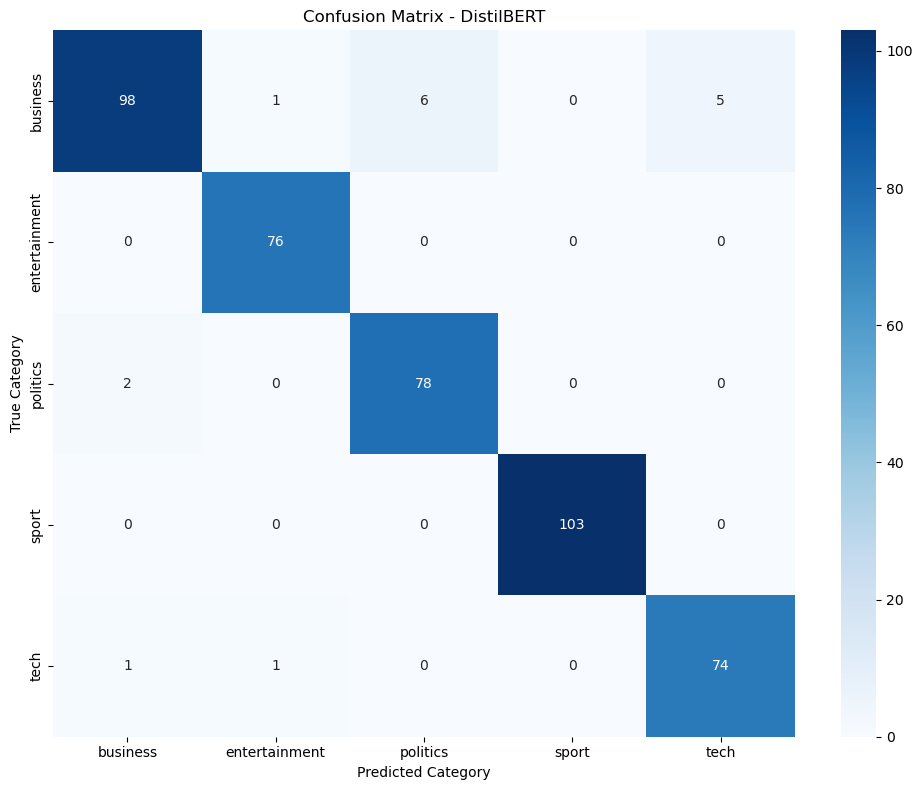

Confusion matrix saved as 'confusion_matrix_distilbert.png'


In [27]:
print("\n" + "="*60)
print("GENERATING CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(test_df['labels'], preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix - DistilBERT')
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.savefig('confusion_matrix_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved as 'confusion_matrix_distilbert.png'")

### ROC Curve


GENERATING ROC CURVES


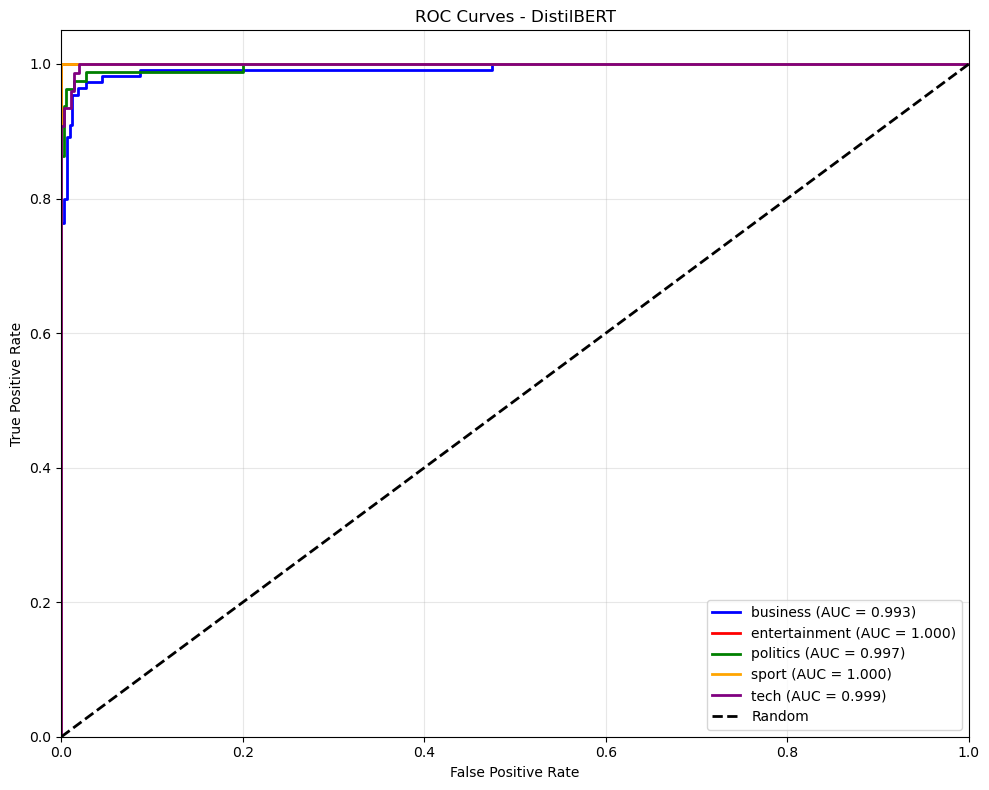


AUC Scores:
  business: 0.9927
  entertainment: 1.0000
  politics: 0.9966
  sport: 1.0000
  tech: 0.9990

ROC curves saved as 'roc_curves_distilbert.png'


In [29]:
print("\n" + "="*60)
print("GENERATING ROC CURVES")
print("="*60)

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(test_df['labels'], classes=range(len(categories)))

fpr = {}
tpr = {}
roc_auc = {}
colors = ['blue', 'red', 'green', 'orange', 'purple']

for i in range(len(categories)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i, (color, category) in enumerate(zip(colors, categories)):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'{category} (AUC = {roc_auc[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - DistilBERT')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAUC Scores:")
for i, category in enumerate(categories):
    print(f"  {category}: {roc_auc[i]:.4f}")

print("\nROC curves saved as 'roc_curves_distilbert.png'")

### Precision-Recall curve


GENERATING PRECISION-RECALL CURVES


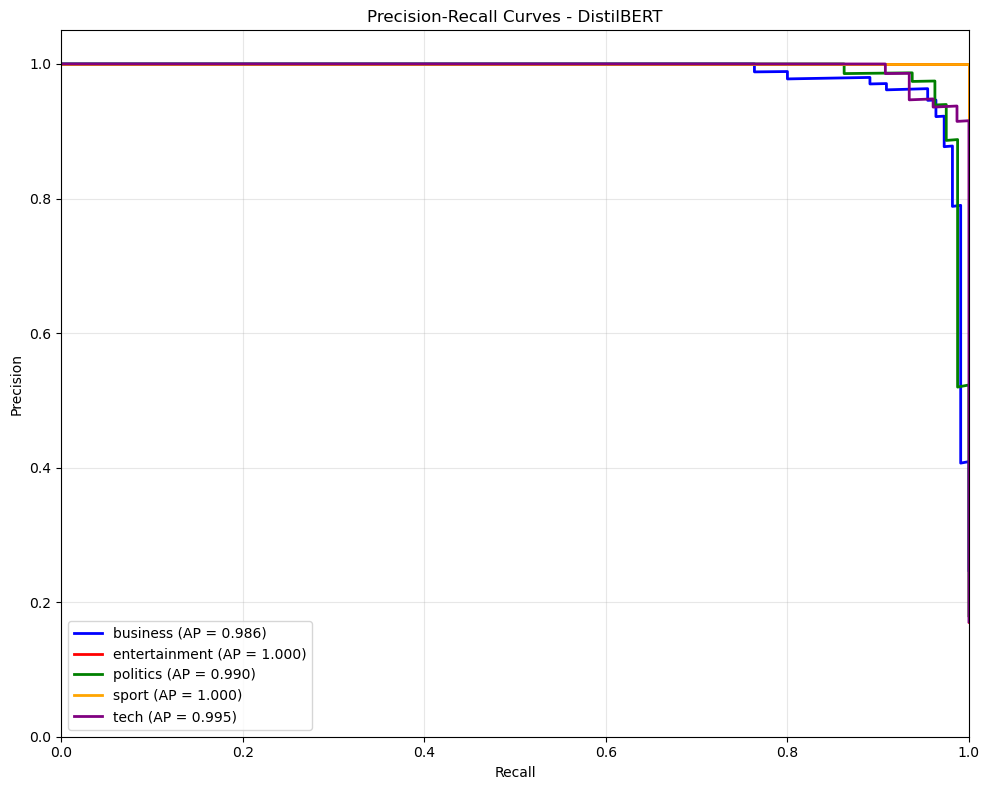


Average Precision Scores:
  business: 0.9858
  entertainment: 1.0000
  politics: 0.9902
  sport: 1.0000
  tech: 0.9955

PR curves saved as 'pr_curves_distilbert.png'


In [31]:
print("\n" + "="*60)
print("GENERATING PRECISION-RECALL CURVES")
print("="*60)

precision_dict = {}
recall_dict = {}
avg_precision = {}

for i in range(len(categories)):
    precision_dict[i], recall_dict[i], _ = precision_recall_curve(
        y_test_bin[:, i], probs[:, i]
    )
    avg_precision[i] = auc(recall_dict[i], precision_dict[i])

plt.figure(figsize=(10, 8))
for i, (color, category) in enumerate(zip(colors, categories)):
    plt.plot(recall_dict[i], precision_dict[i], color=color, lw=2,
             label=f'{category} (AP = {avg_precision[i]:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - DistilBERT')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves_distilbert.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nAverage Precision Scores:")
for i, category in enumerate(categories):
    print(f"  {category}: {avg_precision[i]:.4f}")

print("\nPR curves saved as 'pr_curves_distilbert.png'")

### Making Sample Predictions

In [56]:
import torch

def predict_article(text, return_probs=False):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0]

    probs_np = probs.cpu().numpy()

    all_probs = {
        id2label[i]: float(probs_np[i])
        for i in range(len(probs_np))
    }

    predicted = max(all_probs, key=all_probs.get)
    confidence = all_probs[predicted]

    if return_probs:
        return predicted, confidence, all_probs
    return predicted, confidence


In [60]:
print("\n" + "="*60)
print("TESTING ON CUSTOM ARTICLES")
print("="*60)

# Custom test articles
custom_articles = [
    {
        'text': "Apple announces new iPhone with revolutionary camera technology. The stock price surged 5% after the announcement. Investors are optimistic about the company's future earnings.",
        'expected': 'business'
    },
    {
        'text': "Manchester United defeated Liverpool 3-1 in an exciting Premier League match. Ronaldo scored two goals in the second half to secure the victory.",
        'expected': 'sport'
    },
    {
        'text': "The Prime Minister announced new policies on climate change today. Parliament will vote on the environmental bill next week.",
        'expected': 'politics'
    },
    {
        'text': "New AI model breaks records in natural language processing. Researchers say it can understand context better than previous systems.",
        'expected': 'tech'
    },
    {
        'text': "Taylor Swift's new album breaks streaming records on Spotify. The pop star will embark on a world tour next summer.",
        'expected': 'entertainment'
    }
]

# Test each custom article
print("\nTesting model on custom articles:\n")
results = []

for i, article in enumerate(custom_articles, 1):
    predicted, conf, all_probs = predict_article(article['text'], return_probs=True)
    
    is_correct = predicted == article['expected']
    status = "✓ CORRECT" if is_correct else "✗ WRONG"
    
    print(f"\n{'='*70}")
    print(f"ARTICLE {i}: {status}")
    print(f"{'='*70}")
    print(f"Text: {article['text']}")
    print(f"\nExpected:  {article['expected']}")
    print(f"Predicted: {predicted}")
    print(f"Confidence: {conf:.2%}")
    print(f"\nAll Probabilities:")
    for label, prob in sorted(all_probs.items(), key=lambda x: x[1], reverse=True):
        bar = '█' * int(prob * 50)
        print(f"  {label:15s} {prob:6.2%} {bar}")
    
    results.append({
        'article_num': i,
        'text': article['text'][:50] + '...',
        'expected': article['expected'],
        'predicted': predicted,
        'correct': is_correct,
        'confidence': conf
    })


TESTING ON CUSTOM ARTICLES

Testing model on custom articles:


ARTICLE 1: ✗ WRONG
Text: Apple announces new iPhone with revolutionary camera technology. The stock price surged 5% after the announcement. Investors are optimistic about the company's future earnings.

Expected:  business
Predicted: tech
Confidence: 48.82%

All Probabilities:
  tech            48.82% ████████████████████████
  business        39.79% ███████████████████
  politics         4.32% ██
  entertainment    4.30% ██
  sport            2.77% █

ARTICLE 2: ✓ CORRECT
Text: Manchester United defeated Liverpool 3-1 in an exciting Premier League match. Ronaldo scored two goals in the second half to secure the victory.

Expected:  sport
Predicted: sport
Confidence: 91.22%

All Probabilities:
  sport           91.22% █████████████████████████████████████████████
  tech             2.57% █
  entertainment    2.12% █
  politics         2.06% █
  business         2.03% █

ARTICLE 3: ✓ CORRECT
Text: The Prime Minister announ